Nesta atividade pratica, vou aplicar os conceitos das aulas de Outliers, PCA, KNN e K-Fold Cross Validation em um unico fluxo de analise e classificacao, usando o dataset **wine** do sklearn (13 caracteristicas quimicas, 178 amostras, 3 classes).

O fluxo eh o seguinte: insiro um outlier artificial numa coluna e removo com a func `reject_outliers` (aula de Outliers); reduzo os dados de 13 para 2 dimensoes com PCA; treino um classificador `KNeighborsClassifier` sobre os dados reduzidos e valido o modelo com k-fold cross validation (cv=5).


In [ ]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# importa as bibliotecas utilizadas ao longo do notebook

# carrega o dataset de vinho, disponivel no sklearn (dataset classico de classificacao, semelhante ao iris usado na aula de PCA)
wine = load_wine()

numSamples, numFeatures = wine.data.shape
print(numSamples)   # quantidade de amostras (vinhos)
print(numFeatures)  # quantidade de features (13 medidas quimicas de cada vinho)
print(wine.target_names)  # nomes das 3 classes de vinho

178
13
['class_0' 'class_1' 'class_2']


**1) forçando um outlier fora do padrao em uma coluna**

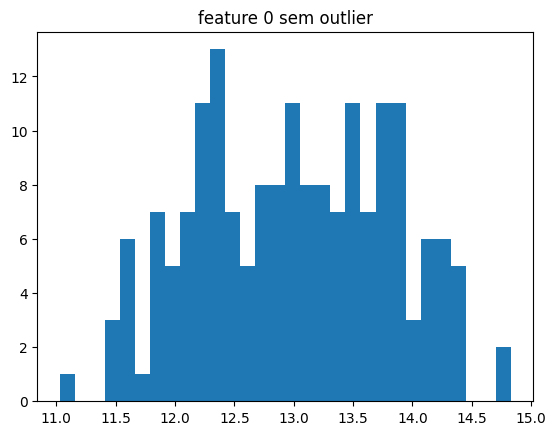

13.00061797752809


In [2]:
# utiliza-se apenas a feature 0 (primeira coluna) e insere-se um outlier bem grande nela,
# de forma semelhante ao que foi feito com a renda (income) na aula de Outliers
feature0 = wine.data[:, 0].copy()

plt.hist(feature0, 30)  # histograma da distribuicao original, sem outlier
plt.title("feature 0 sem outlier")
plt.show()
print(feature0.mean())  # media da distribuicao original, sem distorcoes

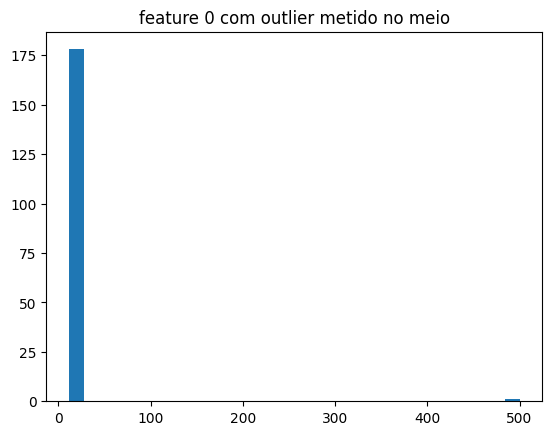

15.721284916201117


In [3]:
# adiciona um valor bem fora da curva (as amostras normais ficam entre ~11 e ~15; aqui o valor eh 500)
feature0_com_outlier = np.append(feature0, [500])

plt.hist(feature0_com_outlier, 30)
plt.title("feature 0 com outlier")
plt.show()
print(feature0_com_outlier.mean())  # a media ja fica distorcida por causa de um unico valor discrepante

**2) limpando o outlier (func copiada da aula de Outliers)**

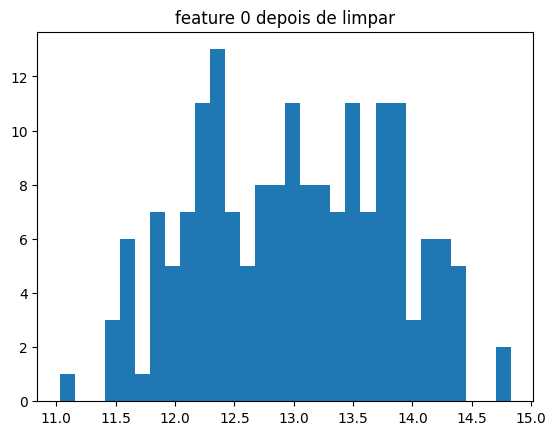

13.00061797752809


In [4]:
def reject_outliers(data):
    u = np.median(data)  # mediana, que ao contrario da media nao eh afetada pelo outlier
    s = np.std(data)      # desvio padrao dos dados
    # mantem apenas os valores dentro de 2 desvios padrao da mediana, descartando o restante (outliers)
    filtered = [e for e in data if (u - 2 * s < e < u + 2 * s)]
    return filtered

feature0_limpo = reject_outliers(feature0_com_outlier)

plt.hist(feature0_limpo, 30)  # sem o outlier, a distribuicao volta a ficar parecida com a original
plt.title("feature 0 depois de limpar")
plt.show()
print(np.mean(feature0_limpo))  # a media volta a ficar proxima do valor original

**3) reduzindo as 13 colunas com PCA**

In [5]:
from sklearn.preprocessing import StandardScaler

# as features do wine tem escalas bem diferentes entre si (uma chega perto de 1000, outra fica so entre 0 e 5);
# por isso, antes do PCA e necessario padronizar os dados (media 0, desvio 1), caso contrario a feature de maior escala dominaria o resultado
x = StandardScaler().fit_transform(wine.data)

# reduz de 13 dimensoes para 2, whiten normaliza a variancia de cada componente
pca = PCA(n_components=2, whiten=True).fit(x)
x_pca = pca.transform(x)  # gera os dados transformados ja em 2D

print(pca.explained_variance_ratio_)      # quanto cada componente explica da variancia total
print(sum(pca.explained_variance_ratio_))  # soma das 2 componentes, mostrando quanta informacao e mantida ao reduzir para 2D

[0.36198848 0.1920749 ]
0.5540633835693527


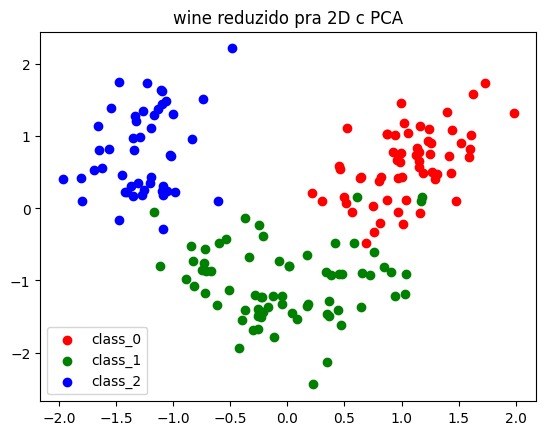

In [6]:
colors = cycle('rgb')  # 3 cores, uma para cada classe de vinho
target_ids = range(len(wine.target_names))
plt.figure()
for i, c, label in zip(target_ids, colors, wine.target_names):
    # plota cada classe de vinho com uma cor diferente, usando as 2 componentes principais
    plt.scatter(x_pca[wine.target == i, 0], x_pca[wine.target == i, 1], c=c, label=label)
plt.legend()
plt.title("wine reduzido para 2D com PCA")
plt.show()  # e possivel perceber que, mesmo com apenas 2 dimensoes, as 3 classes ficam bem separadas

**4) treinando um KNN nos dados ja reduzidos**

In [7]:
# aqui utiliza-se o KNN ja implementado no sklearn (na aula, o KNN foi implementado manualmente para recomendar filmes,
# com distancia de cosseno calculada separadamente; aqui opta-se pelo KNeighborsClassifier, mais direto)
knn = KNeighborsClassifier(n_neighbors=5)  # considera os 5 vizinhos mais proximos para decidir a classe

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    x_pca, wine.target, test_size=0.3, random_state=0
)  # separa 70% dos dados para treino e 30% para teste

knn.fit(X_train, y_train)  # treina o modelo
knn.score(X_test, y_test)  # acuracia obtida nesse split especifico de teste

0.9814814814814815

**5) validando com k-fold cross validation**

In [8]:
# em vez de confiar em um unico split de treino e teste, o modelo e validado com varios folds diferentes
scores = model_selection.cross_val_score(knn, x_pca, wine.target, cv=5)  # cv=5 indica 5 divisoes diferentes

print(scores)         # acuracia obtida em cada um dos 5 folds
print(scores.mean())  # media dos folds, que fornece uma estimativa mais confiavel do desempenho do modelo

[0.94444444 0.94444444 0.97222222 0.97142857 0.97142857]
0.9607936507936508
